In [105]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Load Dataset

In [106]:
DATA_DIR = Path(".")

In [107]:
print(DATA_DIR.exists())
print(list(DATA_DIR.iterdir()))

True
[WindowsPath('.gitignore'), WindowsPath('building_metadata.csv'), WindowsPath('PM Kemajuan Kel 13.pdf'), WindowsPath('Project ML_progress.ipynb'), WindowsPath('README.md'), WindowsPath('train.csv'), WindowsPath('weather_train.csv')]


In [108]:
path_train = DATA_DIR / "train.csv"
path_building = DATA_DIR / "building_metadata.csv"
path_weather = DATA_DIR / "weather_train.csv"

In [109]:
train_df = pd.read_csv(path_train)
building_df = pd.read_csv(path_building)
weather_df = pd.read_csv(path_weather)

In [110]:
print("Train:", train_df.shape)
print("Building:", building_df.shape)
print("Weather:", weather_df.shape)

Train: (20216100, 4)
Building: (1449, 6)
Weather: (139773, 9)


## Reduce memory

In [111]:
def reduce_mem_usage(df, verbose=True):

    numerics = [
        'int16', 'int32', 'int64',
        'float32', 'float64'
    ]

    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:

        col_type = df[col].dtypes

        if col_type in numerics:

            c_min = df[col].min()
            c_max = df[col].max()

            # integer
            if str(col_type)[:3] == 'int':

                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)

                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)

                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)

            # float
            else:

                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)

        end_mem = df.memory_usage().sum() / 1024**2

    if verbose:
        print(
            'Memory usage decreased to {:5.2f} Mb ({:.1f}% reduction)'
            .format(end_mem,
                    100 * (start_mem - end_mem) / start_mem)
        )

    return df

In [112]:
train_df = reduce_mem_usage(train_df)
building_df = reduce_mem_usage(building_df)
weather_df = reduce_mem_usage(weather_df)

Memory usage decreased to 289.19 Mb (53.1% reduction)
Memory usage decreased to  0.03 Mb (52.0% reduction)
Memory usage decreased to  4.93 Mb (48.6% reduction)


In [113]:
print("Train:", train_df.shape)
print("Building:", building_df.shape)
print("Weather:", weather_df.shape)

Train: (20216100, 4)
Building: (1449, 6)
Weather: (139773, 9)


## Merge Dataset

In [114]:
train_df.head()

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.0
1,1,0,2016-01-01 00:00:00,0.0
2,2,0,2016-01-01 00:00:00,0.0
3,3,0,2016-01-01 00:00:00,0.0
4,4,0,2016-01-01 00:00:00,0.0


In [115]:
building_df.head()

,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN


In [116]:
weather_df.head()

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.000000,6.0,20.0,NaN,1019.700012,0.0,0.0
1,0,2016-01-01 01:00:00,24.400000,NaN,21.1,-1.0,1020.200012,70.0,1.5
2,0,2016-01-01 02:00:00,22.799999,2.0,21.1,0.0,1020.200012,0.0,0.0
3,0,2016-01-01 03:00:00,21.100000,2.0,20.6,0.0,1020.099976,0.0,0.0
4,0,2016-01-01 04:00:00,20.000000,2.0,20.0,-1.0,1020.000000,250.0,2.6


In [117]:
train_df = train_df[train_df["meter"] == 0]

print(train_df.shape)

(12060910, 4)


In [118]:
df_full = train_df.merge(
    building_df,
    on='building_id',
    how='left'
)

print(df_full.shape)
df_full.head()

(12060910, 9)


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN
1,1,0,2016-01-01 00:00:00,0.0,0,Education,2720,2004.0,NaN
2,2,0,2016-01-01 00:00:00,0.0,0,Education,5376,1991.0,NaN
3,3,0,2016-01-01 00:00:00,0.0,0,Education,23685,2002.0,NaN
4,4,0,2016-01-01 00:00:00,0.0,0,Education,116607,1975.0,NaN


In [119]:
df_full = df_full.merge(
    weather_df,
    on=['site_id', 'timestamp'],
    how='left'
)

## EDA

In [120]:
print(df_full.shape)
print(df_full.info())

(12060910, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12060910 entries, 0 to 12060909
Data columns (total 16 columns):
 #   Column              Dtype  
---  ------              -----  
 0   building_id         int16  
 1   meter               int8   
 2   timestamp           object 
 3   meter_reading       float32
 4   site_id             int8   
 5   primary_use         object 
 6   square_feet         int32  
 7   year_built          float32
 8   floor_count         float32
 9   air_temperature     float32
 10  cloud_coverage      float32
 11  dew_temperature     float32
 12  precip_depth_1_hr   float32
 13  sea_level_pressure  float32
 14  wind_direction      float32
 15  wind_speed          float32
dtypes: float32(10), int16(1), int32(1), int8(2), object(2)
memory usage: 736.1+ MB
None


Setelah proses penggabungan antara data konsumsi energi, metadata bangunan, dan data cuaca, diperoleh dataset sebanyak 12.060.910 baris dan 16 variabel. Pada tahap ini penelitian difokuskan pada konsumsi energi listrik (electricity) dengan memilih meter = 0, karena listrik merupakan sumber energi yang paling relevan dengan operasional bangunan modern, seperti penggunaan AC, pencahayaan, dan perangkat elektronik. Dataset hasil penggabungan mencakup informasi karakteristik bangunan, seperti jenis bangunan (primary_use), luas bangunan (square_feet), tahun pembangunan (year_built), serta kondisi cuaca, seperti suhu udara (air_temperature), kelembapan (dew_temperature), tekanan udara, dan kecepatan angin yang diperkirakan dapat memengaruhi pola konsumsi energi bangunan.

In [121]:
missing = (
    df_full.isnull()
    .mean()
    .sort_values(ascending=False) * 100
)

missing

floor_count           75.417883
year_built            53.644667
cloud_coverage        44.189468
precip_depth_1_hr     20.841537
sea_level_pressure     8.443666
wind_direction         5.627395
wind_speed             0.553814
dew_temperature        0.407026
air_temperature        0.392383
square_feet            0.000000
site_id                0.000000
primary_use            0.000000
meter                  0.000000
timestamp              0.000000
building_id            0.000000
meter_reading          0.000000
dtype: float64

Hasil identifikasi missing value menunjukkan bahwa beberapa variabel memiliki data kosong dengan proporsi yang cukup tinggi, terutama floor_count (75,4%), year_built (53,6%), dan cloud_coverage (44,2%). Sementara itu, variabel cuaca lain seperti air_temperature, dew_temperature, dan wind_speed memiliki persentase data hilang yang relatif kecil (<1%). Pada tahap preprocessing, penanganan data hilang dilakukan secara berbeda berdasarkan karakteristik variabel. Variabel dengan missing value sangat tinggi seperti floor_count dipertimbangkan untuk dihapus karena berpotensi menambah noise. Untuk year_built, nilai kosong akan diisi menggunakan median agar distribusi data tetap stabil dan tidak terlalu dipengaruhi outlier. Variabel cuaca dengan missing rendah akan diimputasi menggunakan median juga karena masih relevan terhadap konsumsi energi dan kehilangan datanya kecil.

### Distribusi Target

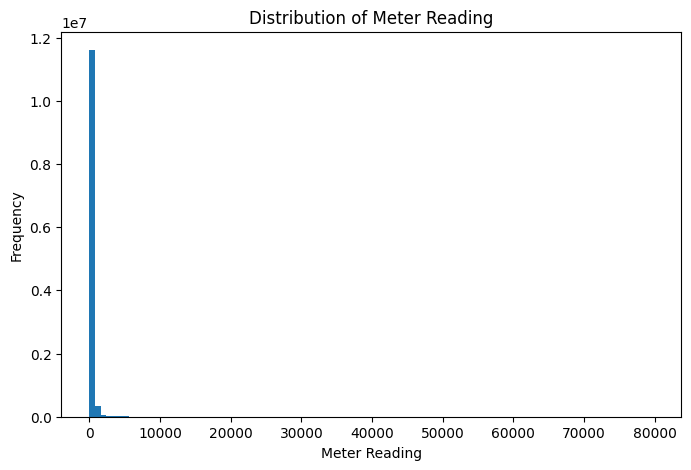

In [122]:
plt.figure(figsize=(8,5))
plt.hist(df_full['meter_reading'], bins=100)
plt.title('Distribution of Meter Reading')
plt.xlabel('Meter Reading')
plt.ylabel('Frequency')
plt.show()

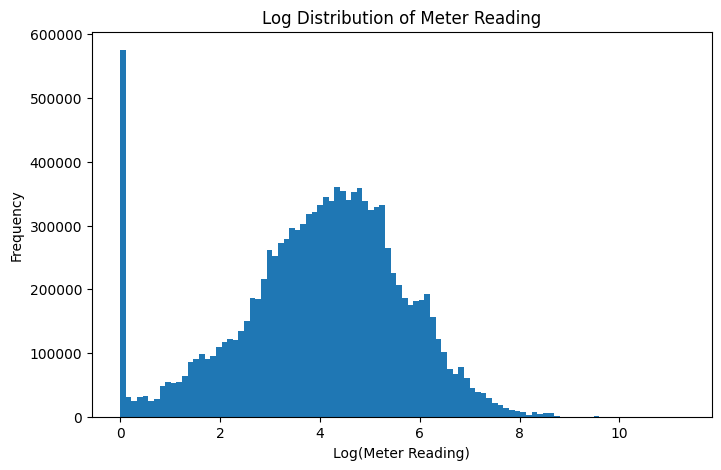

In [123]:
plt.figure(figsize=(8,5))
plt.hist(
    np.log1p(df_full['meter_reading']),
    bins=100
)

plt.title('Log Distribution of Meter Reading')
plt.xlabel('Log(Meter Reading)')
plt.ylabel('Frequency')
plt.show()

Histogram meter_reading menunjukkan distribusi yang sangat right-skewed, di mana sebagian besar observasi berada pada nilai konsumsi energi rendah dan hanya sedikit observasi memiliki nilai sangat tinggi. Untuk memahami pola distribusi secara lebih jelas, dilakukan visualisasi menggunakan transformasi logaritmik (log1p) pada tahap eksplorasi data. Hasil visualisasi menunjukkan distribusi yang lebih menyebar dan stabil, sehingga mengindikasikan bahwa transformasi log layak dipertimbangkan pada tahap preprocessing untuk meningkatkan performa model.

### Distribusi Weather

In [124]:
weather_cols = [
    'air_temperature',
    'dew_temperature',
    'wind_speed',
    'sea_level_pressure'
]

df_full[weather_cols].describe()

,air_temperature,dew_temperature,wind_speed,sea_level_pressure
count,1.201358e+07,1.201182e+07,1.199412e+07,1.104253e+07
mean,1.600965e+01,8.334991e+00,3.559324e+00,1.016408e+03
std,1.039774e+01,9.836796e+00,2.317835e+00,7.035792e+00
min,-2.890000e+01,-3.500000e+01,0.000000e+00,9.682000e+02
25%,8.900000e+00,1.100000e+00,2.100000e+00,1.012100e+03
50%,1.670000e+01,9.400000e+00,3.100000e+00,1.016500e+03
75%,2.390000e+01,1.610000e+01,4.600000e+00,1.020700e+03
max,4.720000e+01,2.610000e+01,1.900000e+01,1.045500e+03


Statistik deskriptif variabel cuaca menunjukkan bahwa dataset mencakup kondisi cuaca yang cukup beragam. air_temperature memiliki median sekitar 16,7°C dengan rentang dari −28,9°C hingga 47,2°C, yang menunjukkan data berasal dari berbagai kondisi iklim, termasuk wilayah dingin dan panas. dew_temperature memiliki median 9,4°C yang menggambarkan variasi kelembapan udara. Sementara itu, wind_speed cenderung rendah dengan median sekitar 3,1, dan sea_level_pressure relatif stabil di sekitar 1016 hPa. Temuan ini menunjukkan bahwa data cuaca masih sangat heterogen dan belum sepenuhnya merepresentasikan kondisi iklim tropis seperti Indonesia, sehingga pada tahap selanjutnya akan dipertimbangkan filtering berdasarkan karakteristik iklim Indonesia dengan dukungan literatur terkait.

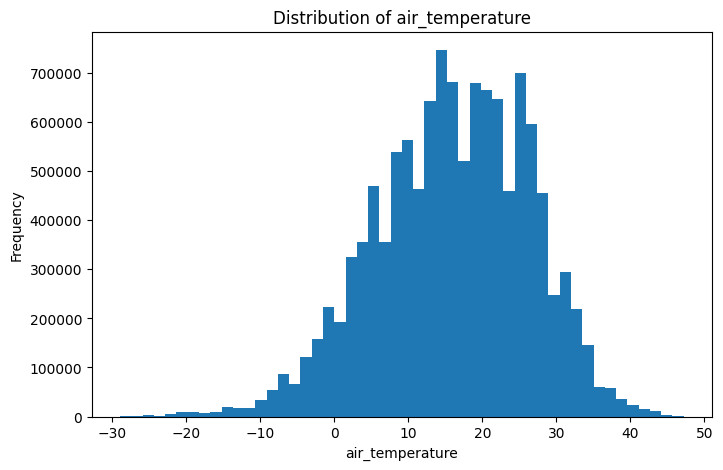

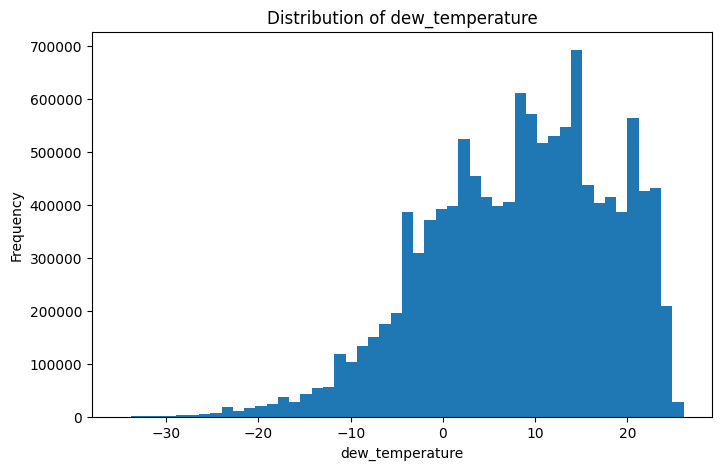

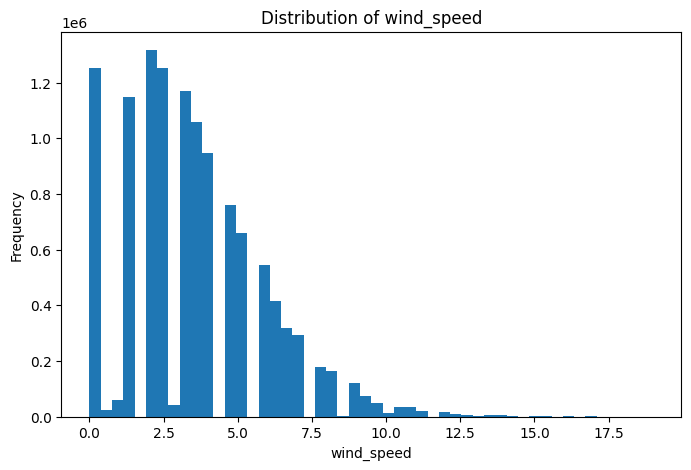

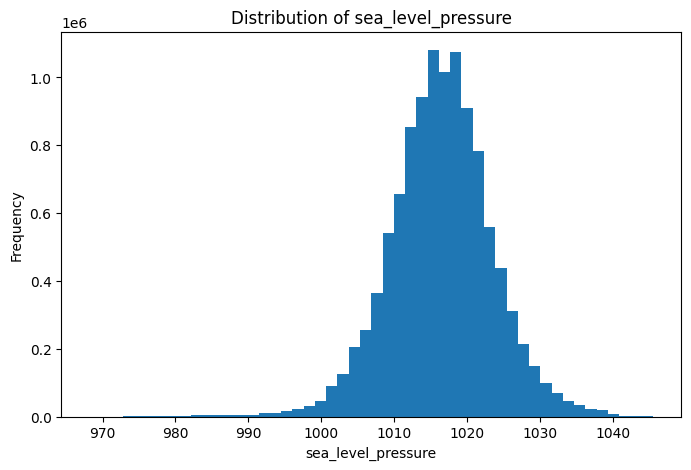

In [125]:
for col in weather_cols:

    plt.figure(figsize=(8,5))

    plt.hist(
        df_full[col].dropna(),
        bins=50
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.show()

Distribusi variabel cuaca menunjukkan pola yang cukup beragam antar fitur. air_temperature memiliki distribusi mendekati normal dengan konsentrasi terbesar pada kisaran suhu sedang (sekitar 10–30°C), namun masih terdapat nilai ekstrem hingga suhu negatif, yang mengindikasikan bahwa dataset mencakup wilayah dengan iklim non-tropis. dew_temperature menunjukkan pola yang relatif serupa dan cenderung terkonsentrasi pada suhu positif, menandakan variasi tingkat kelembapan udara pada berbagai kondisi lingkungan. Variabel wind_speed memiliki distribusi right-skewed, di mana mayoritas kecepatan angin berada pada nilai rendah hingga sedang, sedangkan kecepatan tinggi hanya muncul pada sebagian kecil observasi. Sementara itu, sea_level_pressure terlihat relatif stabil dan mendekati distribusi normal dengan pusat nilai di sekitar 1010–1020 hPa, menunjukkan variasi tekanan udara yang tidak terlalu ekstrem.

### Building Type

In [126]:
df_full['primary_use'].value_counts()

primary_use
Education                        4597256
Office                           2310203
Entertainment/public assembly    1511295
Public services                  1320045
Lodging/residential              1229082
Other                             210764
Parking                           187447
Healthcare                        184345
Warehouse/storage                 103077
Retail                             96618
Manufacturing/industrial           85216
Services                           78951
Technology/science                 45275
Food sales and service             43826
Utility                            32476
Religious worship                  25034
Name: count, dtype: int64

Distribusi primary_use menunjukkan bahwa konsumsi energi didominasi oleh bangunan pendidikan (Education), diikuti kantor (Office), hiburan/fasilitas publik (Entertainment/Public Assembly), layanan publik (Public Services), dan hunian/penginapan (Lodging/Residential). Hal ini menunjukkan bahwa dataset lebih banyak merepresentasikan bangunan dengan aktivitas operasional tinggi dan penggunaan listrik rutin. Sementara itu, kategori seperti Religious worship, Utility, dan Food sales and service memiliki jumlah observasi yang relatif kecil. Pada tahap selanjutnya, distribusi ini akan menjadi dasar evaluasi relevansi jenis bangunan terhadap konteks Indonesia serta pertimbangan apakah kategori tertentu perlu dipertahankan atau disederhanakan agar analisis lebih representatif.

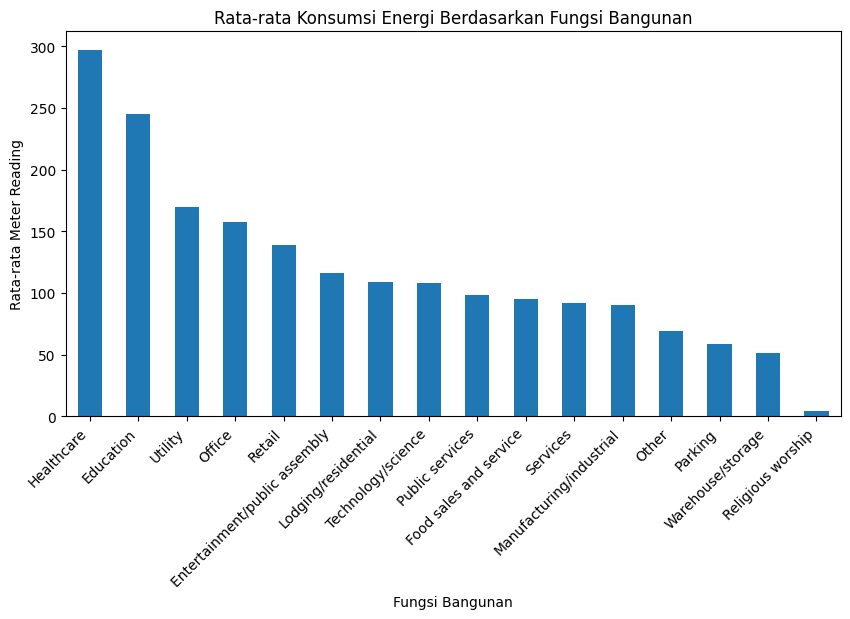

In [127]:
energy_by_use = (
    df_full
    .groupby("primary_use")["meter_reading"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
energy_by_use.plot(kind="bar")
plt.title("Rata-rata Konsumsi Energi Berdasarkan Fungsi Bangunan")
plt.xlabel("Fungsi Bangunan")
plt.ylabel("Rata-rata Meter Reading")
plt.xticks(rotation=45, ha="right")
plt.show()

Rata-rata konsumsi energi berdasarkan fungsi bangunan menunjukkan adanya perbedaan pola penggunaan listrik antar kategori bangunan. Kategori Healthcare memiliki rata-rata konsumsi energi tertinggi, diikuti Education, Utility, dan Office, yang mengindikasikan kebutuhan listrik yang relatif besar untuk mendukung aktivitas operasional, seperti pendingin ruangan, pencahayaan, perangkat elektronik, maupun layanan pendukung lainnya. Sementara itu, kategori seperti Religious worship, Warehouse/storage, dan Parking memiliki rata-rata konsumsi energi yang lebih rendah, yang kemungkinan dipengaruhi oleh intensitas penggunaan bangunan yang tidak berlangsung secara penuh sepanjang waktu.

### Pola Waktu

In [128]:
df_full['timestamp'] = pd.to_datetime(df_full['timestamp'])

In [129]:
df_full['hour'] = df_full['timestamp'].dt.hour
df_full['dayofweek'] = df_full['timestamp'].dt.day_name()
df_full['month'] = df_full['timestamp'].dt.month_name()

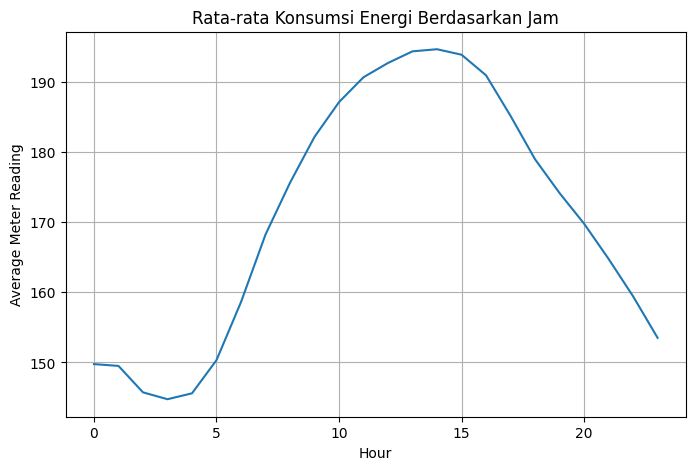

In [130]:
hourly_pattern = (
    df_full
    .groupby('hour')['meter_reading']
    .mean()
)

plt.figure(figsize=(8,5))

plt.plot(hourly_pattern)

plt.title('Rata-rata Konsumsi Energi Berdasarkan Jam')
plt.xlabel('Hour')
plt.ylabel('Average Meter Reading')

plt.grid(True)
plt.show()

Peningkatan konsumsi pada siang hingga sore kemungkinan berkaitan dengan tingginya aktivitas bangunan, terutama pada gedung pendidikan, kantor, dan layanan publik yang mendominasi dataset.

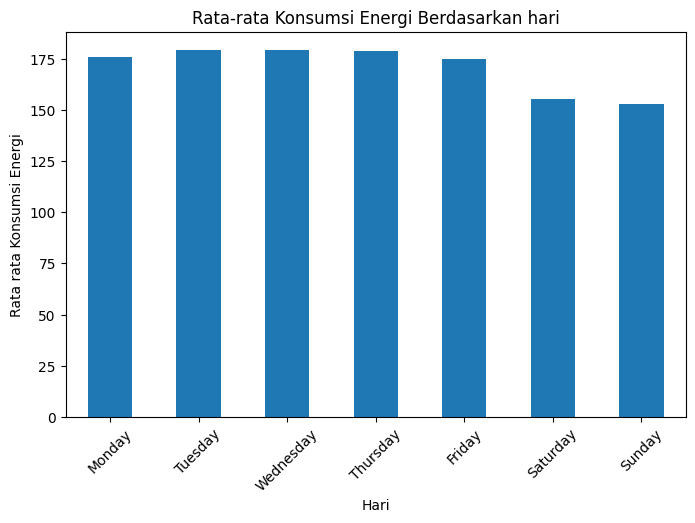

In [131]:
day_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday',
    'Saturday','Sunday'
]

daily_pattern = (
    df_full
    .groupby('dayofweek')['meter_reading']
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(8,5))

daily_pattern.plot(kind='bar')

plt.title('Rata-rata Konsumsi Energi Berdasarkan hari')
plt.xlabel('Hari')
plt.ylabel('Rata rata Konsumsi Energi')

plt.xticks(rotation=45)
plt.show()

Rata-rata konsumsi energi berdasarkan hari menunjukkan pola yang relatif stabil pada hari kerja (Senin–Jumat), dengan konsumsi energi cenderung lebih tinggi pada Selasa hingga Kamis. Sementara itu, terjadi penurunan konsumsi energi pada akhir pekan (Sabtu dan Minggu). Pola ini mengindikasikan bahwa aktivitas operasional bangunan memengaruhi penggunaan listrik, di mana konsumsi energi lebih tinggi pada hari kerja akibat aktivitas pendidikan, perkantoran, dan layanan publik, sedangkan akhir pekan menunjukkan aktivitas yang relatif lebih rendah.

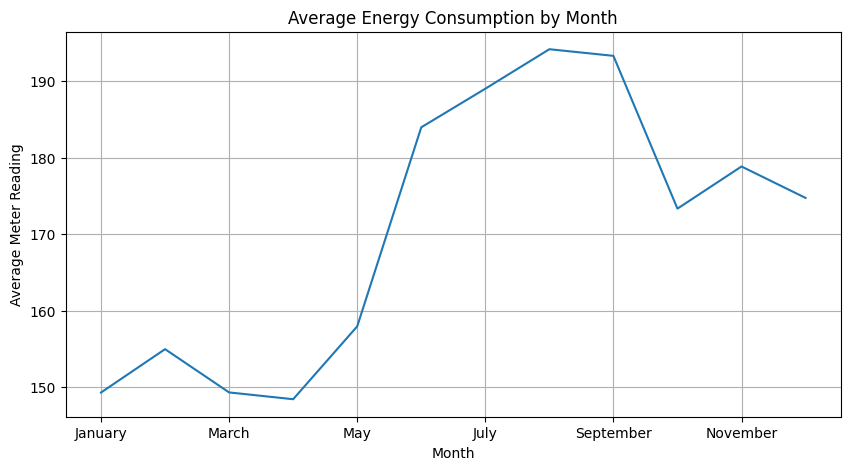

In [132]:
month_order = [
    'January','February','March',
    'April','May','June',
    'July','August','September',
    'October','November','December'
]

monthly_pattern = (
    df_full
    .groupby('month')['meter_reading']
    .mean()
    .reindex(month_order)
)

plt.figure(figsize=(10,5))

monthly_pattern.plot(kind='line')

plt.title('Average Energy Consumption by Month')
plt.xlabel('Month')
plt.ylabel('Average Meter Reading')

plt.grid(True)
plt.show()

Pola konsumsi energi berdasarkan bulan menunjukkan adanya variasi musiman (seasonality) sepanjang tahun. Konsumsi energi relatif lebih rendah pada awal tahun, khususnya sekitar Januari–April, kemudian mulai meningkat sejak pertengahan tahun dan mencapai puncak pada sekitar Agustus–September. Setelah itu, konsumsi energi kembali mengalami penurunan pada akhir tahun. Pola ini mengindikasikan bahwa penggunaan energi kemungkinan dipengaruhi oleh faktor musiman, seperti perubahan kondisi cuaca, kebutuhan pendinginan bangunan, maupun tingkat aktivitas operasional pada periode tertentu.

### Korelasi

In [133]:
numeric_cols = [
    'meter_reading',
    'floor_count',
    'square_feet',
    'air_temperature',
    'dew_temperature',
    'wind_speed',
    'sea_level_pressure'
]

corr = df_full[numeric_cols].corr()

corr

,meter_reading,floor_count,square_feet,air_temperature,dew_temperature,wind_speed,sea_level_pressure
meter_reading,1.000000,0.361107,0.547772,-0.008207,-0.002193,-0.021851,-0.013029
floor_count,0.361107,1.000000,0.536881,-0.186909,-0.179533,-0.011242,-0.055400
square_feet,0.547772,0.536881,1.000000,-0.007031,-0.026972,-0.038885,-0.022481
air_temperature,-0.008207,-0.186909,-0.007031,1.000000,0.758803,-0.076054,-0.285373
dew_temperature,-0.002193,-0.179533,-0.026972,0.758803,1.000000,-0.129833,-0.202125
wind_speed,-0.021851,-0.011242,-0.038885,-0.076054,-0.129833,1.000000,-0.205403
sea_level_pressure,-0.013029,-0.055400,-0.022481,-0.285373,-0.202125,-0.205403,1.000000


Hasil korelasi menunjukkan bahwa square_feet memiliki hubungan positif sedang terhadap meter_reading (0,55), yang mengindikasikan bahwa bangunan dengan ukuran lebih besar cenderung memiliki konsumsi energi lebih tinggi. Sementara itu, variabel cuaca seperti air_temperature, dew_temperature, wind_speed, dan sea_level_pressure menunjukkan korelasi linear yang relatif lemah terhadap konsumsi energi. Hal ini mengindikasikan bahwa pengaruh cuaca terhadap konsumsi energi kemungkinan tidak bersifat langsung atau linear, melainkan dipengaruhi kombinasi faktor lain seperti waktu operasional, jenis bangunan, dan karakteristik lingkungan. Selain itu, terlihat korelasi tinggi antara air_temperature dan dew_temperature (0,76), yang menunjukkan adanya keterkaitan kuat antara suhu udara dan kelembapan.

## Pre-Processing

### Filtering Relevansi Indonesia

In [134]:
df_full['air_temperature'].quantile(
    [0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]
)

0.01   -10.000000
0.05    -1.700000
0.10     2.200000
0.25     8.900000
0.50    16.700001
0.75    23.900000
0.90    28.900000
0.95    31.700001
0.99    37.200001
Name: air_temperature, dtype: float32

In [135]:
indo_mask = df_full['air_temperature'].between(15, 40)

print("Before :", len(df_full))
print("After  :", indo_mask.sum())
print("Remain :", round(
    indo_mask.mean()*100, 2
), "%")

Before : 12060910
After  : 6739305
Remain : 55.88 %


In [136]:
df_full = df_full[
    df_full['air_temperature']
    .between(15, 40)
].copy()

print(df_full.shape)

(6739305, 19)


Untuk meningkatkan relevansi dataset terhadap konteks bangunan di Indonesia, dilakukan filtering pada variabel air_temperature dengan rentang 15–40°C. Pemilihan batas suhu ini didasarkan pada kombinasi literatur BMKG dan hasil eksplorasi distribusi data (quantile analysis). Berdasarkan informasi BMKG, suhu udara ekstrem terendah di Indonesia umumnya terjadi pada wilayah dataran tinggi seperti Dieng (Jawa Tengah) dan Puncak Jaya (Papua Tengah), yang pada kondisi tertentu dapat mencapai sekitar −2°C hingga −5°C. Namun kondisi tersebut bersifat sangat lokal dan tidak merepresentasikan mayoritas wilayah Indonesia.

Selain mempertimbangkan literatur, pemilihan batas bawah juga mengacu pada distribusi data hasil eksplorasi. Analisis quantile menunjukkan bahwa median (Q50) temperatur dataset hanya sebesar 16,7°C, yang berarti sekitar 50% observasi memiliki suhu di bawah 16,7°C. Kondisi ini dinilai kurang representatif terhadap karakteristik iklim Indonesia yang didominasi wilayah tropis hangat, karena daerah dengan suhu rendah di Indonesia relatif terbatas dan hanya terjadi pada wilayah tertentu seperti pegunungan atau dataran tinggi. Oleh karena itu, dipilih batas bawah 15°C sebagai kompromi agar tetap mengakomodasi wilayah dingin Indonesia, namun sekaligus mengurangi dominasi observasi dari wilayah beriklim dingin non-Indonesia yang tidak relevan dengan tujuan penelitian. Dengan filtering ini, sekitar 55,88% observasi (±6,7 juta data) tetap dipertahankan sehingga dataset masih cukup besar untuk proses pemodelan.

### mengatasi Missing Value

In [137]:
missing = (
    df_full.isnull()
    .mean()
    .sort_values(ascending=False) * 100
)

print(missing)

floor_count           79.002968
year_built            53.660147
cloud_coverage        41.111079
precip_depth_1_hr     12.269455
wind_direction         7.563584
sea_level_pressure     4.696864
wind_speed             0.242295
dew_temperature        0.013814
timestamp              0.000000
building_id            0.000000
meter                  0.000000
air_temperature        0.000000
site_id                0.000000
primary_use            0.000000
square_feet            0.000000
meter_reading          0.000000
hour                   0.000000
dayofweek              0.000000
month                  0.000000
dtype: float64


In [138]:
drop_cols = [
    'wind_direction',
    'floor_count'
]

df_full.drop(
    columns=[col for col in drop_cols if col in df_full.columns],
    inplace=True
)

fill_cols = [
    'year_built',
    'cloud_coverage',
    'precip_depth_1_hr',
    'sea_level_pressure',
    'wind_speed',
    'dew_temperature'
]

for col in fill_cols:
    df_full[col] = df_full[col].fillna(
        df_full[col].median()
    )

In [139]:
missing = (
    df_full.isnull()
    .mean()
    .sort_values(ascending=False) * 100
)

missing

building_id           0.0
meter                 0.0
timestamp             0.0
meter_reading         0.0
site_id               0.0
primary_use           0.0
square_feet           0.0
year_built            0.0
air_temperature       0.0
cloud_coverage        0.0
dew_temperature       0.0
precip_depth_1_hr     0.0
sea_level_pressure    0.0
wind_speed            0.0
hour                  0.0
dayofweek             0.0
month                 0.0
dtype: float64

Penghapusan variabel wind_direction dan floor_count dilakukan dengan pertimbangan yang berbeda. Variabel wind_direction dihapus karena dinilai kurang memberikan kontribusi yang signifikan terhadap prediksi konsumsi energi bangunan dan memiliki relevansi yang lebih rendah dibanding variabel cuaca lainnya, seperti suhu udara, kecepatan angin, maupun tekanan udara. Sementara itu, variabel floor_count dihapus karena memiliki proporsi missing value yang sangat tinggi sehingga berpotensi menurunkan kualitas pemodelan apabila dipertahankan.

Selanjutnya, missing value pada variabel year_built, cloud_coverage, precip_depth_1_hr, sea_level_pressure, wind_speed, dan dew_temperature ditangani menggunakan metode imputasi median. Metode median dipilih karena lebih robust terhadap distribusi data yang tidak normal dan keberadaan outlier dibandingkan rata-rata (mean).

### Feature Engineering

In [140]:
df_full['timestamp'] = pd.to_datetime(df_full['timestamp'])

df_full['hour'] = df_full['timestamp'].dt.hour
df_full['dayofweek'] = df_full['timestamp'].dt.dayofweek
df_full['month'] = df_full['timestamp'].dt.month

In [141]:
df_full[['timestamp', 'hour', 'dayofweek', 'month']].head()

,timestamp,hour,dayofweek,month
0,2016-01-01,0,4,1
1,2016-01-01,0,4,1
2,2016-01-01,0,4,1
3,2016-01-01,0,4,1
4,2016-01-01,0,4,1


In [142]:
df_full.drop(columns=['timestamp'], inplace=True)

Pada tahap feature engineering, dilakukan ekstraksi informasi waktu dari variabel timestamp dengan membentuk fitur baru berupa hour, dayofweek, dan month. Fitur hour digunakan untuk menangkap pola konsumsi energi berdasarkan jam penggunaan bangunan, dayofweek untuk membedakan pola konsumsi antara hari kerja dan akhir pekan, serta month untuk menangkap pola musiman atau perubahan konsumsi energi berdasarkan periode waktu tertentu. Proses ini dilakukan agar model dapat mengenali pola temporal yang berpotensi memengaruhi konsumsi energi bangunan.

### Encoding

In [143]:
df_full['primary_use'].unique()

array(['Education', 'Lodging/residential', 'Office',
       'Entertainment/public assembly', 'Other', 'Retail', 'Parking',
       'Public services', 'Warehouse/storage', 'Food sales and service',
       'Religious worship', 'Healthcare', 'Utility', 'Technology/science',
       'Services', 'Manufacturing/industrial'], dtype=object)

In [144]:
df_full = pd.get_dummies(
    df_full,
    columns=['primary_use'],
    drop_first=False,
    dtype=int
)

In [145]:
df_full.filter(like='primary_use').sum()

primary_use_Education                        2491945
primary_use_Entertainment/public assembly     894823
primary_use_Food sales and service             25806
primary_use_Healthcare                         88217
primary_use_Lodging/residential               737772
primary_use_Manufacturing/industrial           31444
primary_use_Office                           1212248
primary_use_Other                             144327
primary_use_Parking                           125898
primary_use_Public services                   762278
primary_use_Religious worship                  14484
primary_use_Retail                             63336
primary_use_Services                           49495
primary_use_Technology/science                 17951
primary_use_Utility                            17537
primary_use_Warehouse/storage                  61744
dtype: int64

In [146]:
df_full.columns[df_full.columns.str.contains('primary_use')]

Index(['primary_use_Education', 'primary_use_Entertainment/public assembly',
       'primary_use_Food sales and service', 'primary_use_Healthcare',
       'primary_use_Lodging/residential',
       'primary_use_Manufacturing/industrial', 'primary_use_Office',
       'primary_use_Other', 'primary_use_Parking',
       'primary_use_Public services', 'primary_use_Religious worship',
       'primary_use_Retail', 'primary_use_Services',
       'primary_use_Technology/science', 'primary_use_Utility',
       'primary_use_Warehouse/storage'],
      dtype='object')

In [147]:
df_full.filter(like='primary_use').head()

,primary_use_Education,primary_use_Entertainment/public assembly,primary_use_Food sales and service,primary_use_Healthcare,primary_use_Lodging/residential,primary_use_Manufacturing/industrial,primary_use_Office,primary_use_Other,primary_use_Parking,primary_use_Public services,primary_use_Religious worship,primary_use_Retail,primary_use_Services,primary_use_Technology/science,primary_use_Utility,primary_use_Warehouse/storage
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


dilakukan proses encoding terhadap variabel kategorikal primary_use menggunakan metode One-Hot Encoding. Variabel primary_use merepresentasikan jenis fungsi bangunan, seperti Education, Office, Retail, Healthcare, Lodging/residential, dan kategori lainnya. Karena algoritma machine learning seperti Random Forest dan XGBoost tidak dapat memproses data bertipe kategorikal secara langsung, maka kategori tersebut perlu dikonversi menjadi format numerik.

### Transform Target

In [148]:
df_full['meter_reading_log'] = np.log1p(df_full['meter_reading'])

Pada tahap preprocessing lanjutan, dilakukan transformasi terhadap variabel target (meter_reading) menggunakan fungsi logaritma untuk mengurangi skewness (kemencengan distribusi) pada data konsumsi energi. Pemilihan log1p dilakukan karena variabel meter_reading memiliki distribusi yang sangat tidak merata (right-skewed) dengan rentang nilai yang besar serta banyak nilai nol. Penggunaan transformasi log membantu mengurangi pengaruh nilai ekstrem (outlier) dan membuat distribusi target menjadi lebih stabil.

### Split Feature Target

In [149]:
df_full.reset_index(drop=True, inplace=True)

In [150]:
X = df_full.drop(
    ['meter_reading', 'meter_reading_log'],
    axis=1
)

y = df_full['meter_reading_log']

In [151]:
print(X.shape)
print(y.shape)

(6739305, 30)
(6739305,)


Tahap berikutnya adalah pemisahan antara feature (X) dan target (y). Feature (X) merupakan seluruh variabel prediktor yang digunakan untuk memprediksi konsumsi energi, sedangkan target (y) merupakan variabel yang ingin diprediksi oleh model. Variabel meter-reading dan meter_reading_log dihapus dari feature untuk mencegah data leakage, yaitu kondisi ketika model memperoleh informasi target secara langsung sehingga menghasilkan performa yang bias dan tidak realistis.

## Modelling

### Train-test Split

In [154]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Random Forest

#### Parameter Pertama

In [155]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=30,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

#### Parameter kedua

In [176]:
rf_model_2 = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model_2.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

#### Parameter ketiga

In [177]:
rf_model_3 = RandomForestRegressor(
    n_estimators=15,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_model_3.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",15
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

### Evaluasi Random Forest

In [156]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [159]:
rf_pred = rf_model.predict(X_test)

In [178]:
rf_pred_2 = rf_model_2.predict(X_test)

In [179]:
rf_pred_3 = rf_model_3.predict(X_test)

#### Parameter pertama

In [160]:
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("=== Random Forest ===")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

=== Random Forest ===
MAE : 0.35178843691138945
RMSE: 0.6298505669698875
R²  : 0.8731244026968082


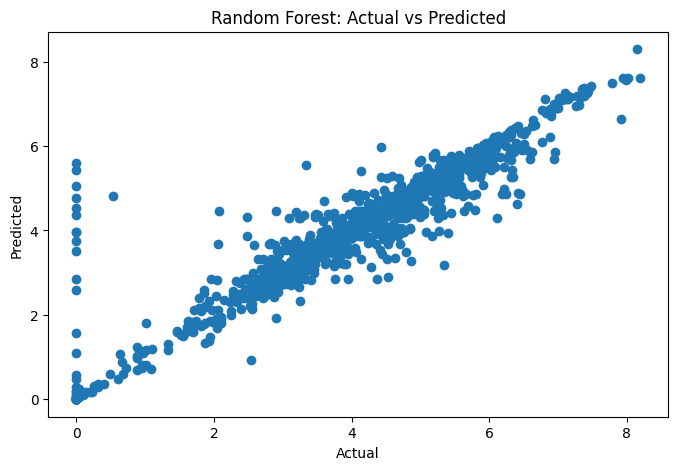

In [180]:
sample_idx = np.random.choice(len(y_test), 1000, replace=False)

plt.figure(figsize=(8,5))
plt.scatter(
    y_test.iloc[sample_idx],
    rf_pred[sample_idx]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

#### Parameter kedua

In [181]:
rf_mae_2 = mean_absolute_error(y_test, rf_pred_2)
rf_rmse_2 = np.sqrt(mean_squared_error(y_test, rf_pred_2))
rf_r2_2 = r2_score(y_test, rf_pred_2)

print("=== Random Forest ===")
print("MAE :", rf_mae_2)
print("RMSE:", rf_rmse_2)
print("R²  :", rf_r2_2)

=== Random Forest ===
MAE : 0.2101149192630123
RMSE: 0.45694721529408
R²  : 0.9332217366368644


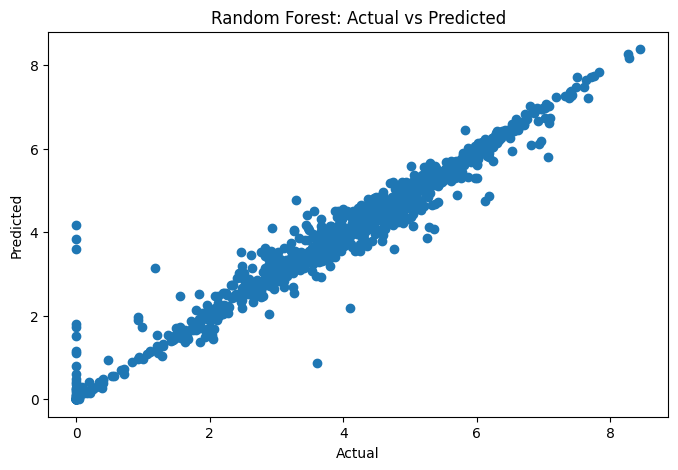

In [182]:
sample_idx = np.random.choice(len(y_test), 1000, replace=False)

plt.figure(figsize=(8,5))
plt.scatter(
    y_test.iloc[sample_idx],
    rf_pred_2[sample_idx]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

#### Parameter ketiga

In [183]:
rf_mae_3 = mean_absolute_error(y_test, rf_pred_3)
rf_rmse_3 = np.sqrt(mean_squared_error(y_test, rf_pred_3))
rf_r2_3 = r2_score(y_test, rf_pred_3)

print("=== Random Forest ===")
print("MAE :", rf_mae_3)
print("RMSE:", rf_rmse_3)
print("R²  :", rf_r2_3)

=== Random Forest ===
MAE : 0.6337704749988948
RMSE: 0.9496880111030204
R²  : 0.7115537072671181


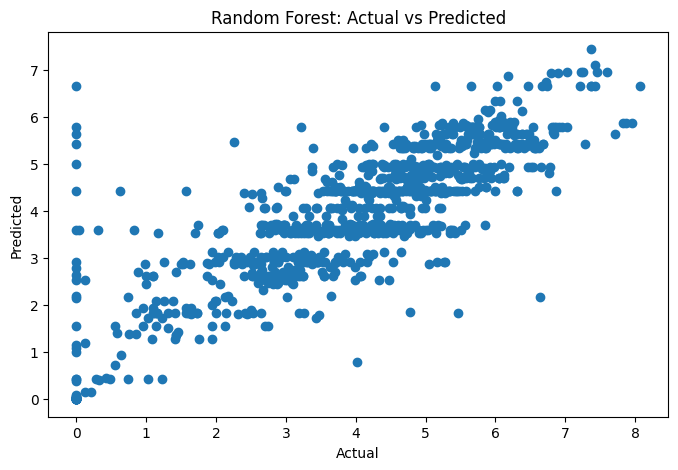

In [184]:
sample_idx = np.random.choice(len(y_test), 1000, replace=False)

plt.figure(figsize=(8,5))
plt.scatter(
    y_test.iloc[sample_idx],
    rf_pred_3[sample_idx]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

#### Perbandingan Evaluasi dan Pemilihan terbaik

In [185]:
Perbandingan_rf = pd.DataFrame({
    'Parameter': [
        'P1 (30 trees, depth=15)',
        'P2 (50 trees, depth=20)',
        'P3 (15 trees, depth=8)'
    ],
    'MAE': [
        rf_mae,
        rf_mae_2,
        rf_mae_3
    ],
    'RMSE': [
        rf_rmse,
        rf_rmse_2,
        rf_rmse_3
    ],
    'R2': [
        rf_r2,
        rf_r2_2,
        rf_r2_3
    ]
})

Perbandingan_rf

,Parameter,MAE,RMSE,R2
0,"P1 (30 trees, depth=15)",0.351788,0.629851,0.873124
1,"P2 (50 trees, depth=20)",0.210115,0.456947,0.933222
2,"P3 (15 trees, depth=8)",0.633770,0.949688,0.711554


Berdasarkan proses hyperparameter tuning, parameter kedua (n_estimators=50, max_depth=20) dipilih sebagai konfigurasi terbaik, karena menghasilkan nilai MAE dan RMSE paling rendah serta R² paling tinggi, sehingga memiliki kemampuan prediksi konsumsi energi bangunan yang lebih akurat dibanding parameter lainnya.

#### Perbandingan Train VS Test

In [186]:
train_pred = rf_model_2.predict(X_train)

In [187]:
test_pred = rf_model_2.predict(X_test)

In [188]:
# TRAIN
train_mae = mean_absolute_error(y_train, train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
train_r2 = r2_score(y_train, train_pred)

# TEST
test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2 = r2_score(y_test, test_pred)

In [189]:
overfit_check = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'MAE': [train_mae, test_mae],
    'RMSE': [train_rmse, test_rmse],
    'R2': [train_r2, test_r2]
})

overfit_check.round(4)

,Dataset,MAE,RMSE,R2
0,Train,0.1976,0.4320,0.9404
1,Test,0.2101,0.4569,0.9332


Berdasarkan perbandingan performa model pada data training dan testing, model Random Forest dengan konfigurasi parameter terbaik (n_estimators=50, max_depth=20) tidak menunjukkan indikasi overfitting. Hal ini ditunjukkan oleh nilai evaluasi pada data training dan testing yang relatif konsisten dengan selisih MAE, RMSE, dan R² yang kecil. Nilai R² pada data training sebesar 0,9404 dan pada data testing sebesar 0,9332 menunjukkan model mampu melakukan generalisasi dengan baik terhadap data baru tanpa kehilangan performa secara signifikan. Dengan demikian, model dinilai stabil dan cukup optimal dalam memprediksi konsumsi energi bangunan.

### Xgboost

In [162]:
from xgboost import XGBRegressor

#### Parameter pertama

In [163]:
xgb_model = XGBRegressor(
    n_estimators=30,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

#### Parameter Kedua

In [167]:
xgb_model_2 = XGBRegressor(
    n_estimators=50,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

xgb_model_2.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

#### Parameter Ketiga

In [170]:
xgb_model_3 = XGBRegressor(
    n_estimators=15,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

xgb_model_3.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

### Evaluasi

In [164]:
xgb_pred = xgb_model.predict(X_test)

In [168]:
xgb_pred_2 = xgb_model_2.predict(X_test)

In [171]:
xgb_pred_3 = xgb_model_3.predict(X_test)

#### Parameter pertama

In [165]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_r2 = r2_score(y_test, xgb_pred)

print("=== XGBoost Evaluation ===")
print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")

=== XGBoost Evaluation ===
MAE  : 0.1559
RMSE : 0.3107
R²   : 0.9691


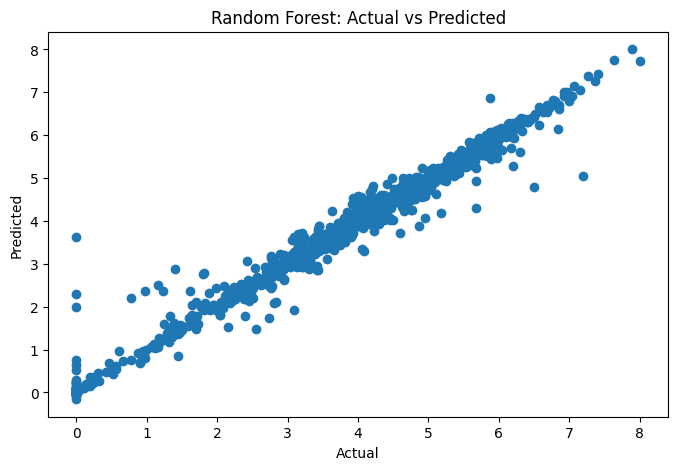

In [173]:
sample_idx = np.random.choice(len(y_test), 1000, replace=False)

plt.figure(figsize=(8,5))
plt.scatter(
    y_test.iloc[sample_idx],
    xgb_pred[sample_idx]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

#### Parameter kedua

In [169]:
xgb_mae_2 = mean_absolute_error(y_test, xgb_pred_2)

xgb_rmse_2 = np.sqrt(
    mean_squared_error(y_test, xgb_pred_2)
)

xgb_r2_2 = r2_score(y_test, xgb_pred_2)

print("=== XGBoost Evaluation ===")
print(f"MAE  : {xgb_mae_2:.4f}")
print(f"RMSE : {xgb_rmse_2:.4f}")
print(f"R²   : {xgb_r2_2:.4f}")

=== XGBoost Evaluation ===
MAE  : 0.1032
RMSE : 0.2410
R²   : 0.9814


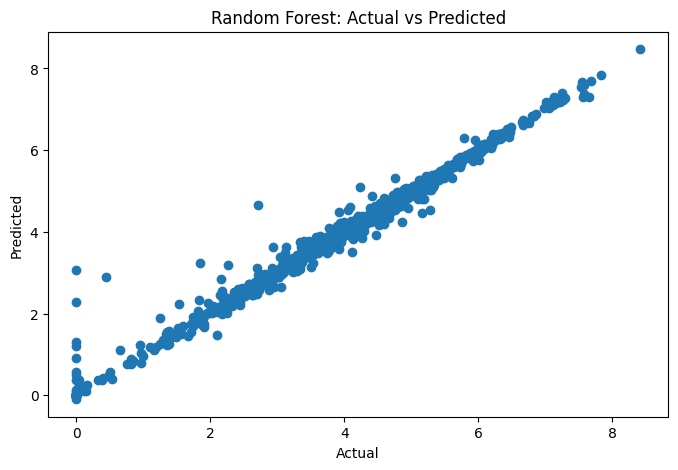

In [174]:
sample_idx = np.random.choice(len(y_test), 1000, replace=False)

plt.figure(figsize=(8,5))
plt.scatter(
    y_test.iloc[sample_idx],
    xgb_pred_2[sample_idx]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

#### Parameter ketiga

In [172]:
xgb_mae_3 = mean_absolute_error(y_test, xgb_pred_3)

xgb_rmse_3 = np.sqrt(
    mean_squared_error(y_test, xgb_pred_3)
)

xgb_r2_3 = r2_score(y_test, xgb_pred_3)

print("=== XGBoost Evaluation ===")
print(f"MAE  : {xgb_mae_3:.4f}")
print(f"RMSE : {xgb_rmse_3:.4f}")
print(f"R²   : {xgb_r2_3:.4f}")

=== XGBoost Evaluation ===
MAE  : 0.4780
RMSE : 0.7441
R²   : 0.8229


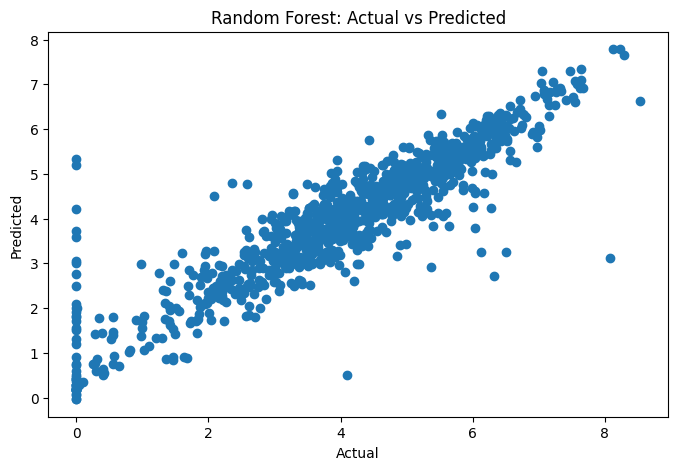

In [175]:
sample_idx = np.random.choice(len(y_test), 1000, replace=False)

plt.figure(figsize=(8,5))
plt.scatter(
    y_test.iloc[sample_idx],
    xgb_pred_3[sample_idx]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

#### Perbandingan Evaluasi dan Pemilihan Parameter Terbaik

In [190]:
Perbandingan_xgb = pd.DataFrame({
    'Parameter': [
        'P1 (30 trees, depth=15)',
        'P2 (50 trees, depth=20)',
        'P3 (15 trees, depth=8)'
    ],
    'MAE': [
        xgb_mae,
        xgb_mae_2,
        xgb_mae_3
    ],
    'RMSE': [
        xgb_rmse,
        xgb_rmse_2,
        xgb_rmse_3
    ],
    'R2': [
        xgb_r2,
        xgb_r2_2,
        xgb_r2_3
    ]
})

Perbandingan_xgb.round(4)

,Parameter,MAE,RMSE,R2
0,"P1 (30 trees, depth=15)",0.1559,0.3107,0.9691
1,"P2 (50 trees, depth=20)",0.1032,0.2410,0.9814
2,"P3 (15 trees, depth=8)",0.4780,0.7441,0.8229


Berdasarkan proses hyperparameter tuning, parameter kedua (n_estimators=50, max_depth=20) dipilih sebagai konfigurasi terbaik, karena menghasilkan nilai MAE dan RMSE paling rendah serta nilai R² paling tinggi dibanding parameter lainnya.

#### Perbandingan Train vs Test

In [191]:
train_pred_xgb = xgb_model_2.predict(X_train)
test_pred_xgb = xgb_model_2.predict(X_test)

In [192]:
train_mae_xgb = mean_absolute_error(y_train, train_pred_xgb)
train_rmse_xgb = np.sqrt(mean_squared_error(y_train, train_pred_xgb))
train_r2_xgb = r2_score(y_train, train_pred_xgb)

test_mae_xgb = mean_absolute_error(y_test, test_pred_xgb)
test_rmse_xgb = np.sqrt(mean_squared_error(y_test, test_pred_xgb))
test_r2_xgb = r2_score(y_test, test_pred_xgb)

overfit_check_xgb = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'MAE': [train_mae_xgb, test_mae_xgb],
    'RMSE': [train_rmse_xgb, test_rmse_xgb],
    'R2': [train_r2_xgb, test_r2_xgb]
})

overfit_check_xgb.round(4)

,Dataset,MAE,RMSE,R2
0,Train,0.0473,0.0853,0.9977
1,Test,0.1032,0.2410,0.9814


#### Cek kenapa bagus

In [193]:
X.columns.tolist()

['building_id',
 'meter',
 'site_id',
 'square_feet',
 'year_built',
 'air_temperature',
 'cloud_coverage',
 'dew_temperature',
 'precip_depth_1_hr',
 'sea_level_pressure',
 'wind_speed',
 'hour',
 'dayofweek',
 'month',
 'primary_use_Education',
 'primary_use_Entertainment/public assembly',
 'primary_use_Food sales and service',
 'primary_use_Healthcare',
 'primary_use_Lodging/residential',
 'primary_use_Manufacturing/industrial',
 'primary_use_Office',
 'primary_use_Other',
 'primary_use_Parking',
 'primary_use_Public services',
 'primary_use_Religious worship',
 'primary_use_Retail',
 'primary_use_Services',
 'primary_use_Technology/science',
 'primary_use_Utility',
 'primary_use_Warehouse/storage']

In [194]:
X_no_building = X.drop('building_id', axis=1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_building,
    y,
    test_size=0.2,
    random_state=42
)

In [195]:
xgb_check = XGBRegressor(
    n_estimators=50,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

xgb_check.fit(X_train2, y_train2)

pred_check = xgb_check.predict(X_test2)

print(r2_score(y_test2, pred_check))

0.965244472026825


Untuk memastikan model tidak terlalu bergantung pada identitas bangunan (building_id), dilakukan pengujian tambahan dengan menghapus variabel tersebut dari fitur pelatihan. Hasil menunjukkan nilai R² hanya mengalami penurunan kecil dari 0,9814 menjadi 0,9652, sehingga dapat disimpulkan bahwa performa model tidak semata-mata dipengaruhi oleh identitas bangunan, melainkan tetap mampu mempelajari pola konsumsi energi dari fitur lain seperti kondisi cuaca, karakteristik bangunan, dan faktor waktu. Dengan demikian, model dinilai memiliki kemampuan generalisasi yang baik.